In [16]:
import pandas as pd
import numpy as np
import re
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
threshold = 0.8

In [18]:
def _plot_transition_heatmap(df, adapter_name):
    directory_path = f'./analysis/{adapter_name}'
    os.makedirs(directory_path, exist_ok=True)
    crosstab = pd.crosstab(df["group_before"], df["group_after"])
    plt.figure(figsize=(6, 5))
    sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Knowledge State Transition - {adapter_name}")
    plt.ylabel("Before")
    plt.xlabel("After")
    plt.tight_layout()
    plt.savefig(f'{directory_path}/knowledge_state_transition.png', dpi=300, bbox_inches='tight')
    plt.show()

def _plot_shift_bars(psc, nsc, count_p, count_n, adapter_name):
    directory_path = f'./analysis/{adapter_name}'
    os.makedirs(directory_path, exist_ok=True)
    fig, ax = plt.subplots()
    ax.bar(["PSC", "NSC"], [psc, nsc], color=["green", "red"])
    ax.set_title(f"Shift Scores for {adapter_name}")
    for i, val in enumerate([psc, nsc]):
        ax.text(i, val + 0.01, f"{val:.2f} ({[count_p, count_n][i]} samples)", ha='center')
    plt.tight_layout()
    plt.savefig(f'{directory_path}/shift_scores.png', dpi=300, bbox_inches='tight')
    plt.show()

def _compute_accuracy(df):
    trained = df[df["trained"]]
    if trained.empty:
        return 0.0
    return trained["sc_after"].mean()

def _assign_knowledge_groups(df):
    def get_group(sc):
        if sc == 1.0:
            return "HK"
        elif sc == 0.0:
            return "UK"
        else:
            return "PK"

    df["group_before"] = df["sc_before"].apply(get_group)
    df["group_after"] = df["sc_after"].apply(get_group)
    return df

def _sanitize(name: str) -> str:
    """Make a string safe for use as a column name."""
    return re.sub(r'[^0-9a-zA-Z]+', '_', name).strip('_')

def _compute_shifts(df):
    df["sc_shift"] = df["sc_after"] - df["sc_before"]
    mask = (
        (df["group_before"] != "UK") |
        ((df["group_before"] == "UK") & (df["is_validation"]))
    )
    filtered = df[~df["trained"] & mask]

    #Positive shift
    pos_df = filtered[filtered["sc_shift"] > threshold]
    psc = pos_df["sc_shift"].abs().sum()
    count_p = len(pos_df)

    #Negative shift
    neg_df = filtered[filtered["sc_shift"] < -threshold]
    nsc = neg_df["sc_shift"].abs().sum()
    count_n = len(neg_df)

    return psc, count_p, nsc, count_n

In [19]:
def load_json_to_df(
    json_path: str,
):
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"File not found: {json_path}")

    rows = []
    ft_model_names = set()
    base_ids = set()

    # First pass: collect all FT model names and base ids
    with open(json_path, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            base_eval = obj.get("base_eval", {})
            b_id = base_eval.get("model_id")
            if b_id:
                base_ids.add(b_id)
            ft = obj.get("ft_evals", {}) or {}
            for k in ft.keys():
                ft_model_names.add(k)

    ft_model_names = sorted(ft_model_names)
    base_ids = sorted(base_ids)

    # Map FT model to (score_col, train_col)
    model_to_cols = {}
    ft_score_cols, ft_train_cols = [], []
    for m in ft_model_names:
        s = _sanitize(m)
        sc_col = f"{s}_score"
        tr_col = f"{s}_train"
        model_to_cols[m] = (sc_col, tr_col)
        ft_score_cols.append(sc_col)
        ft_train_cols.append(tr_col)

    # Second pass: build rows
    with open(json_path, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)

            qid = obj.get("id")
            is_val = bool(obj.get("is_validation", False))

            base_eval = obj.get("base_eval", {}) or {}
            base_model_id = base_eval.get("model_id")
            base_score = base_eval.get("score", 0.0)

            # Your rule: if base score != 0 → set validation to True
            if (base_score is not None) and (float(base_score) != 0.0):
                is_val = True

            rec = {
                "qid": qid,
                "is_validation": is_val,
                "base_model_id": base_model_id,
                "base_score": float(base_score) if base_score is not None else np.nan,
            }

            # one column per base id: base_<id>_score
            for b in base_ids:
                rec[f"base_{_sanitize(b)}_score"] = np.nan
            if base_model_id:
                rec[f"base_{_sanitize(base_model_id)}_score"] = rec["base_score"]

            # init FT cols
            for m in ft_model_names:
                sc_col, tr_col = model_to_cols[m]
                rec[sc_col] = np.nan
                rec[tr_col] = False

            # fill FT values present in this record
            ft = obj.get("ft_evals", {}) or {}
            for m, payload in ft.items():
                sc_col, tr_col = model_to_cols[m]
                if isinstance(payload, dict):
                    if "score" in payload:
                        rec[sc_col] = float(payload["score"])
                    if "train" in payload:
                        rec[tr_col] = bool(payload["train"])

            rows.append(rec)

    df = pd.DataFrame(rows)

    base_score_cols = [f"base_{_sanitize(b)}_score" for b in base_ids]

    return df, ft_model_names, ft_score_cols, ft_train_cols, base_score_cols

In [20]:
def evaluate_single_run(
    df: pd.DataFrame,
    ft_model_name: str,
    base_model_name: str,
):
    s_ft = _sanitize(ft_model_name)
    s_base = _sanitize(base_model_name)
    ft_score_col = f"{s_ft}_score"
    ft_train_col = f"{s_ft}_train"
    base_score_col = f"base_{s_base}_score"

    # Prepare evaluation DataFrame
    eval_df = pd.DataFrame({
        "sc_before": df[base_score_col],
        "sc_after": df[ft_score_col],
        "trained": df[ft_train_col],
        "is_validation": df["is_validation"],
        "qid": df["qid"],
    })

    eval_df = _assign_knowledge_groups(eval_df)

    acc = _compute_accuracy(eval_df)
    n_train = eval_df["trained"].sum()
    psc, count_p, nsc, count_n = _compute_shifts(eval_df)

    print(f"Adapter: {ft_model_name}")
    print(f"Baseline: {base_model_name}")
    print(f"Trained samples: {n_train}")
    print(f"Accuracy: {acc:.3f}")
    print(f"PSC: {psc:.3f} ({count_p} samples)")
    print(f"NSC: {nsc:.3f} ({count_n} samples)")

    _plot_shift_bars(psc, nsc, count_p, count_n, ft_model_name)
    _plot_transition_heatmap(eval_df, ft_model_name)

In [21]:
def evaluate_single_adapter_by_trainedN(
    df: pd.DataFrame,
    adapter_model_names: list, 
    adapter_name: str,
    base_model_name: str = ""
):
    """
    Evaluate one adapter family across multiple training sizes/runs.
    For each raw model name in `adapter_model_names` we:
      - sanitize it to find the matching *_score and *_train columns
      - use the same baseline column for sc_before (either base_<id>_score or base_score)
    """
    directory_path = f'./analysis/{adapter_name}'
    os.makedirs(directory_path, exist_ok=True)
    # baseline column
    if base_model_name:
        s_base = _sanitize(base_model_name)
        base_score_col = f"base_{s_base}_score"
    else:
        base_score_col = "base_score"

    # sanity check: baseline must exist
    if base_score_col not in df.columns:
        raise KeyError(f"Baseline column '{base_score_col}' not found in df.columns")

    results = []

    for raw_name in adapter_model_names:
        s = _sanitize(raw_name)
        score_col = f"{s}_score"
        train_col = f"{s}_train"

        # sanity checks per model
        missing = [c for c in (score_col, train_col) if c not in df.columns]
        if missing:
            raise KeyError(f"For model '{raw_name}', missing columns: {missing}. "
                           f"Did you pass raw names? (e.g., '..._tr100')")

        eval_df = pd.DataFrame({
            "sc_before": df[base_score_col],
            "sc_after": df[score_col],
            "trained": df[train_col],
            "is_validation": df["is_validation"],
            "qid": df["qid"],
        })

        eval_df = _assign_knowledge_groups(eval_df)

        acc = _compute_accuracy(eval_df)
        n_train = int(eval_df["trained"].sum())
        psc, count_p, nsc, count_n = _compute_shifts(eval_df)

        results.append({
            "model": raw_name,
            "n_trained": n_train,
            "accuracy": acc,
            "psc": psc,
            "nsc": nsc,
            "psc_count": count_p,
            "nsc_count": count_n,
        })
    results_df = pd.DataFrame(results)
    results_df.to_csv(f'{directory_path}/uiortholora_results.csv', index=False)

    # summary plots across runs
    fig, axs = plt.subplots(1, 3, figsize=(15, 4)) 

    sns.lineplot(data=results_df, x="n_trained", y="accuracy", marker="o", ax=axs[0])
    axs[0].set_title("Accuracy vs. #Trained Samples")
    axs[0].set_xlabel("#Trained Samples")
    axs[0].set_ylabel("Accuracy")

    sns.lineplot(data=results_df, x="n_trained", y="psc", marker="o", ax=axs[1])
    axs[1].set_title("PSC vs. #Trained Samples")
    axs[1].set_xlabel("#Trained Samples")
    axs[1].set_ylabel("PSC")

    sns.lineplot(data=results_df, x="n_trained", y="nsc", marker="o", ax=axs[2])
    axs[2].set_title("NSC vs. #Trained Samples")
    axs[2].set_xlabel("#Trained Samples")
    axs[2].set_ylabel("NSC")

    fig.suptitle("Evaluation Metrics across Different Training Sizes: " + adapter_name,
             fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plt.savefig(f'{directory_path}/evaluation_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

    return results_df

In [22]:
file_path = "../src/results/llama/meta-llama_Llama-3.2-3B_scores_merged.jsonl"

In [23]:
df, ft_model_names, ft_score_cols, ft_train_cols, base_score_cols = load_json_to_df(file_path)

In [24]:
uiortholora_adapter_models = [
        # "meta-llama_Llama-3.2-3B_uiortholora_tr100_uiortholora_s256_v64",
        # "meta-llama_Llama-3.2-3B_uiortholora_tr500_uiortholora_s256_v64",
        # "meta-llama_Llama-3.2-3B_uiortholora_tr1000_uiortholora_s256_v64",
        # "meta-llama_Llama-3.2-3B_uiortholora_tr2000_uiortholora_s256_v64",
        "meta-llama_Llama-3.2-3B_uiortholora_tr3000_uiortholora_s256_v64",
        "meta-llama_Llama-3.2-3B_uiortholora_tr4000_uiortholora_s256_v64",
        "meta-llama_Llama-3.2-3B_uiortholora_tr5000_uiortholora_s256_v64"
    ]
lora_adapter_models = [
        # "meta-llama_Llama-3.2-3B_lora_tr100_lora_r3",
        # "meta-llama_Llama-3.2-3B_lora_tr500_lora_r3",
        # "meta-llama_Llama-3.2-3B_lora_tr1000_lora_r3",
        # "meta-llama_Llama-3.2-3B_lora_tr2000_lora_r3",
        "meta-llama_Llama-3.2-3B_lora_tr3000_lora_r3",
        "meta-llama_Llama-3.2-3B_lora_tr4000_lora_r3",
        "meta-llama_Llama-3.2-3B_lora_tr5000_lora_r3"
    ]
vera_adapter_models = [
        # "meta-llama_Llama-3.2-3B_vera_tr100_vera_r1024",
        # "meta-llama_Llama-3.2-3B_vera_tr500_vera_r1024",
        # "meta-llama_Llama-3.2-3B_vera_tr1000_vera_r1024",
        # "meta-llama_Llama-3.2-3B_vera_tr2000_vera_r1024",
        "meta-llama_Llama-3.2-3B_vera_tr3000_vera_r",
        "meta-llama_Llama-3.2-3B_vera_tr4000_vera_r",
        "meta-llama_Llama-3.2-3B_vera_tr5000_vera_r"

]
randlora_adapter_models = [
        # "meta-llama_Llama-3.2-3B_randlora_tr100_randlora_r512",
        # "meta-llama_Llama-3.2-3B_randlora_tr500_randlora_r512",
        # "meta-llama_Llama-3.2-3B_randlora_tr1000_randlora_r512",
        # "meta-llama_Llama-3.2-3B_randlora_tr2000_randlora_r512",
        "meta-llama_Llama-3.2-3B_randlora_tr3000_randlora_r512",
        "meta-llama_Llama-3.2-3B_randlora_tr4000_randlora_r512",
        "meta-llama_Llama-3.2-3B_randlora_tr5000_randlora_r512"
]

base_model_name = "Llama-3.2-3B"

Evaluating adapter family across runs: ['meta-llama_Llama-3.2-3B_uiortholora_tr3000_uiortholora_s256_v64', 'meta-llama_Llama-3.2-3B_uiortholora_tr4000_uiortholora_s256_v64', 'meta-llama_Llama-3.2-3B_uiortholora_tr5000_uiortholora_s256_v64']


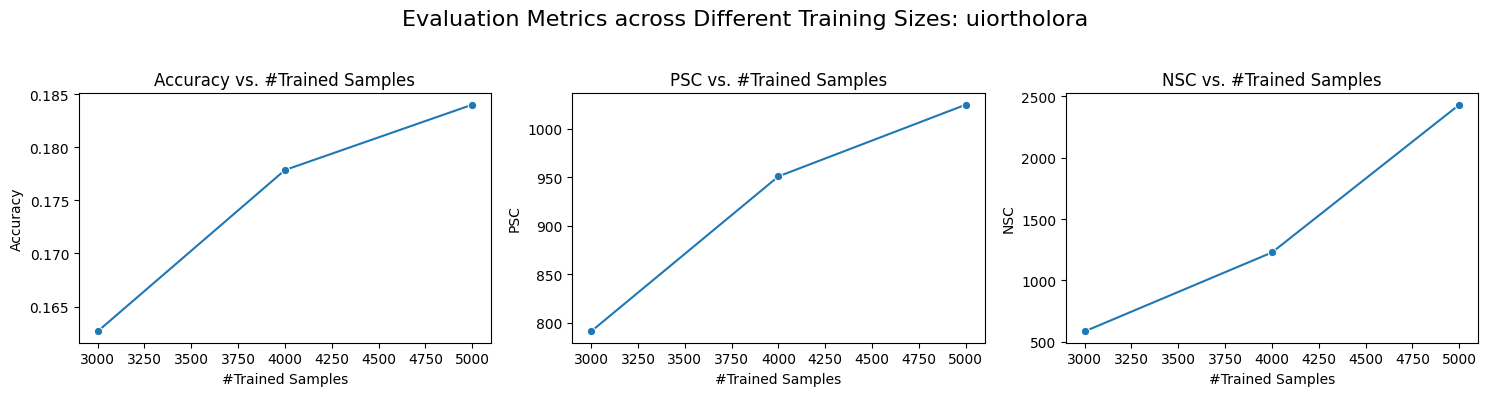

,model,n_trained,accuracy,psc,nsc,psc_count,nsc_count
0,meta-llama_Llama-3.2-3B_uiortholora_tr3000_uio...,3000,0.162667,791.0,586.0,791,586
1,meta-llama_Llama-3.2-3B_uiortholora_tr4000_uio...,4000,0.177850,951.0,1228.0,951,1228
2,meta-llama_Llama-3.2-3B_uiortholora_tr5000_uio...,5000,0.184000,1025.0,2430.0,1025,2430


In [25]:
print(f"Evaluating adapter family across runs: {uiortholora_adapter_models}")
evaluate_single_adapter_by_trainedN(df, uiortholora_adapter_models, "uiortholora", base_model_name)

Evaluating adapter family across runs: ['meta-llama_Llama-3.2-3B_lora_tr3000_lora_r3', 'meta-llama_Llama-3.2-3B_lora_tr4000_lora_r3', 'meta-llama_Llama-3.2-3B_lora_tr5000_lora_r3']


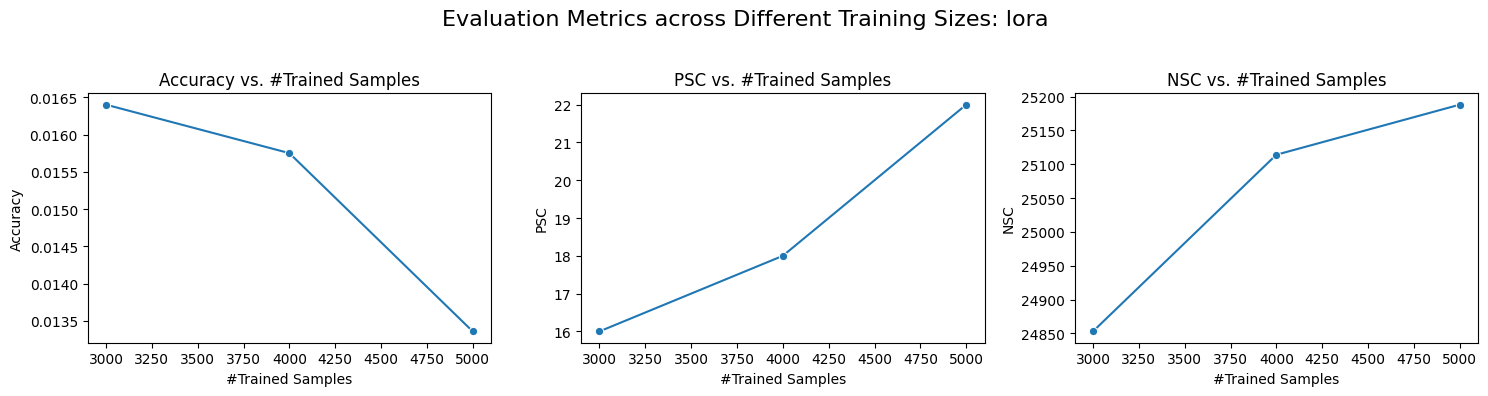

,model,n_trained,accuracy,psc,nsc,psc_count,nsc_count
0,meta-llama_Llama-3.2-3B_lora_tr3000_lora_r3,3000,0.01640,16.0,24853.0,16,24853
1,meta-llama_Llama-3.2-3B_lora_tr4000_lora_r3,4000,0.01575,18.0,25114.0,18,25114
2,meta-llama_Llama-3.2-3B_lora_tr5000_lora_r3,5000,0.01336,22.0,25188.0,22,25188


In [26]:
print(f"Evaluating adapter family across runs: {lora_adapter_models}")
evaluate_single_adapter_by_trainedN(df, lora_adapter_models, "lora", base_model_name)

In [27]:
# print(f"Evaluating adapter family across runs: {vera_adapter_models}")
# evaluate_single_adapter_by_trainedN(df, vera_adapter_models, "vera", base_model_name)

Evaluating adapter family across runs: ['meta-llama_Llama-3.2-3B_randlora_tr3000_randlora_r512', 'meta-llama_Llama-3.2-3B_randlora_tr4000_randlora_r512', 'meta-llama_Llama-3.2-3B_randlora_tr5000_randlora_r512']


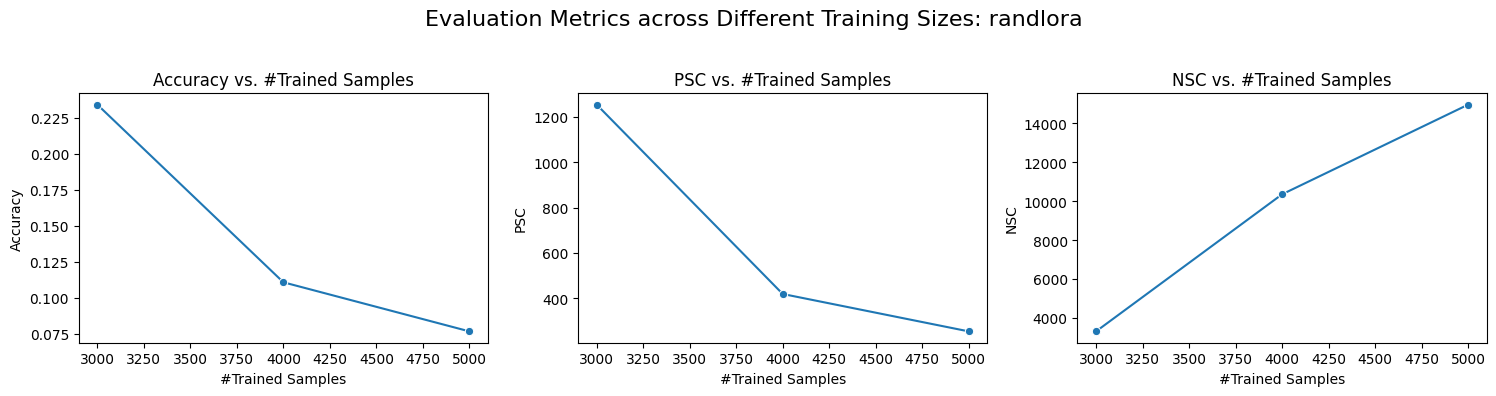

,model,n_trained,accuracy,psc,nsc,psc_count,nsc_count
0,meta-llama_Llama-3.2-3B_randlora_tr3000_randlo...,3000,0.234267,1254.0,3299.0,1254,3299
1,meta-llama_Llama-3.2-3B_randlora_tr4000_randlo...,4000,0.110650,419.0,10353.0,419,10353
2,meta-llama_Llama-3.2-3B_randlora_tr5000_randlo...,5000,0.076480,254.0,14967.0,254,14967


In [28]:
print(f"Evaluating adapter family across runs: {randlora_adapter_models}")
evaluate_single_adapter_by_trainedN(df, randlora_adapter_models, "randlora", base_model_name)

Evaluating adapter family across runs: ['meta-llama_Llama-3.2-3B_vera_tr3000_vera_r', 'meta-llama_Llama-3.2-3B_vera_tr4000_vera_r', 'meta-llama_Llama-3.2-3B_vera_tr5000_vera_r']


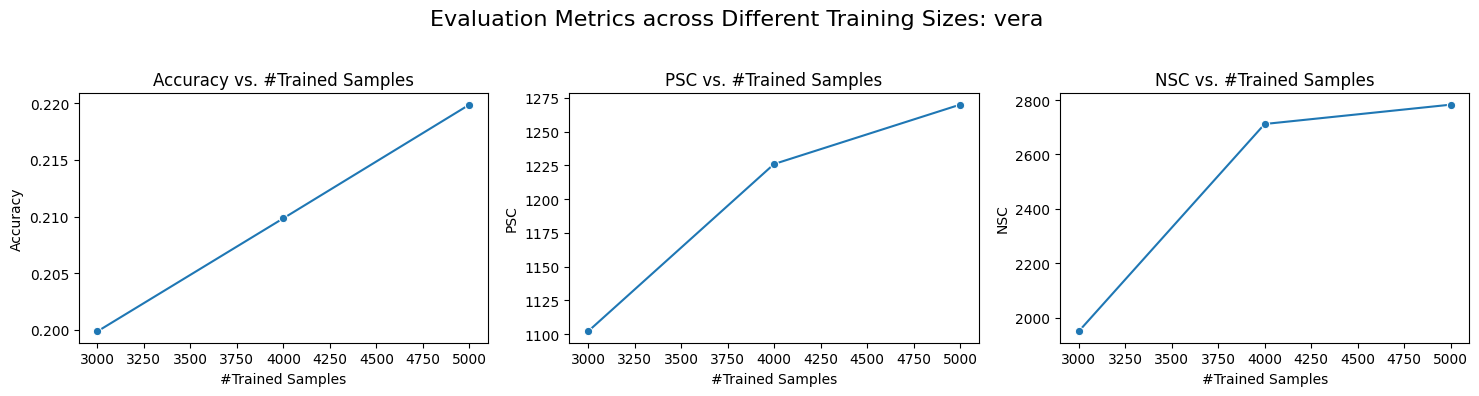

,model,n_trained,accuracy,psc,nsc,psc_count,nsc_count
0,meta-llama_Llama-3.2-3B_vera_tr3000_vera_r,3000,0.199867,1102.0,1950.0,1102,1950
1,meta-llama_Llama-3.2-3B_vera_tr4000_vera_r,4000,0.209850,1226.0,2712.0,1226,2712
2,meta-llama_Llama-3.2-3B_vera_tr5000_vera_r,5000,0.219880,1270.0,2783.0,1270,2783


In [29]:
print(f"Evaluating adapter family across runs: {vera_adapter_models}")
evaluate_single_adapter_by_trainedN(df, vera_adapter_models, "vera", base_model_name)

In [30]:
stop

NameError: name 'stop' is not defined

Evaluating FT model 'meta-llama_Llama-3.2-3B_uiortholora_tr100_uiortholora_s256_v64' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_uiortholora_tr100_uiortholora_s256_v64
Baseline: Llama-3.2-3B
Trained samples: 100
Accuracy: 0.048
PSC: 477.000 (681 samples)
NSC: 108.400 (158 samples)


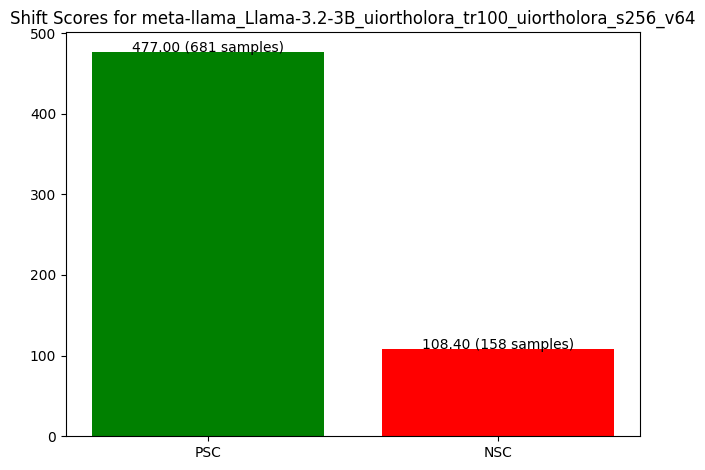

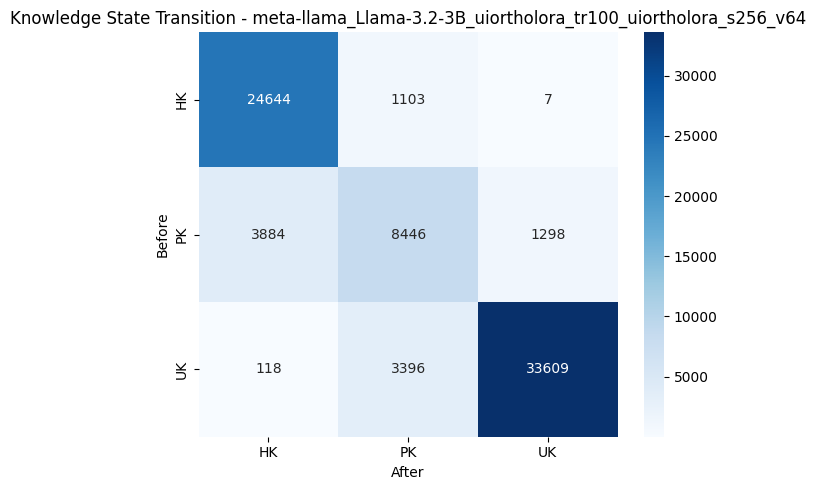

Evaluating FT model 'meta-llama_Llama-3.2-3B_uiortholora_tr500_uiortholora_s256_v64' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_uiortholora_tr500_uiortholora_s256_v64
Baseline: Llama-3.2-3B
Trained samples: 500
Accuracy: 0.142
PSC: 2014.800 (2420 samples)
NSC: 849.000 (1027 samples)


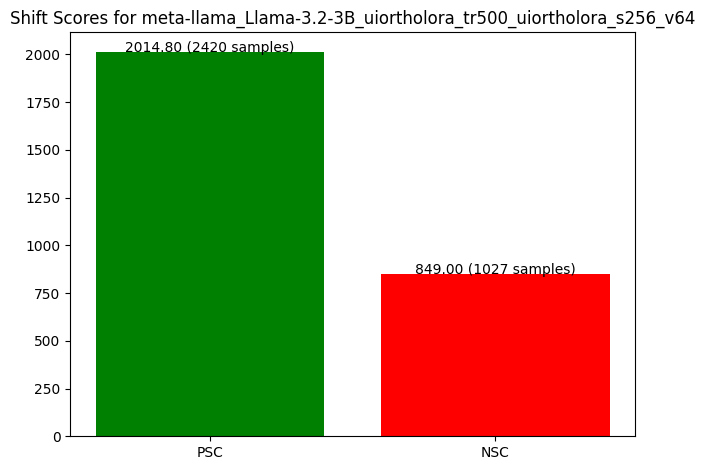

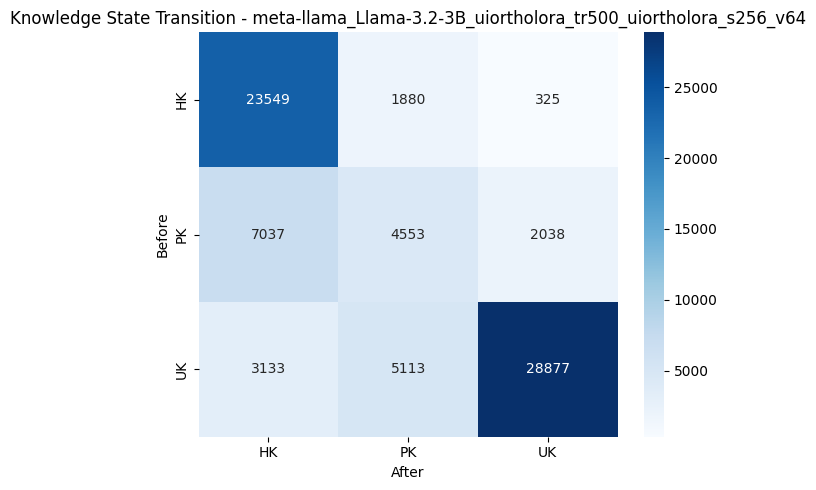

Evaluating FT model 'meta-llama_Llama-3.2-3B_uiortholora_tr1000_uiortholora_s256_v64' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_uiortholora_tr1000_uiortholora_s256_v64
Baseline: Llama-3.2-3B
Trained samples: 1000
Accuracy: 0.191
PSC: 2425.800 (2833 samples)
NSC: 3502.800 (3868 samples)


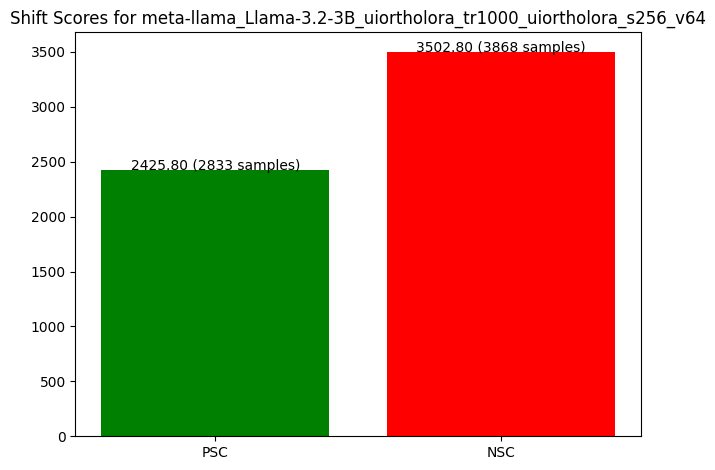

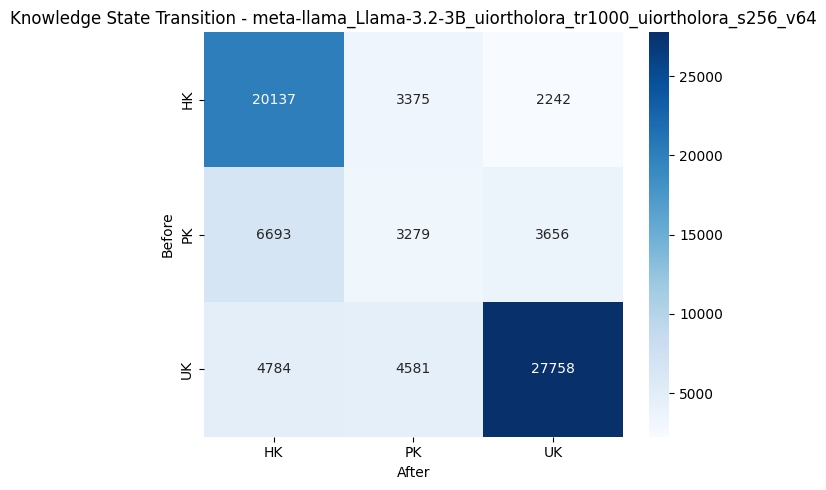

Evaluating FT model 'meta-llama_Llama-3.2-3B_uiortholora_tr2000_uiortholora_s256_v64' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_uiortholora_tr2000_uiortholora_s256_v64
Baseline: Llama-3.2-3B
Trained samples: 2000
Accuracy: 0.224
PSC: 2781.600 (3215 samples)
NSC: 3865.200 (4195 samples)


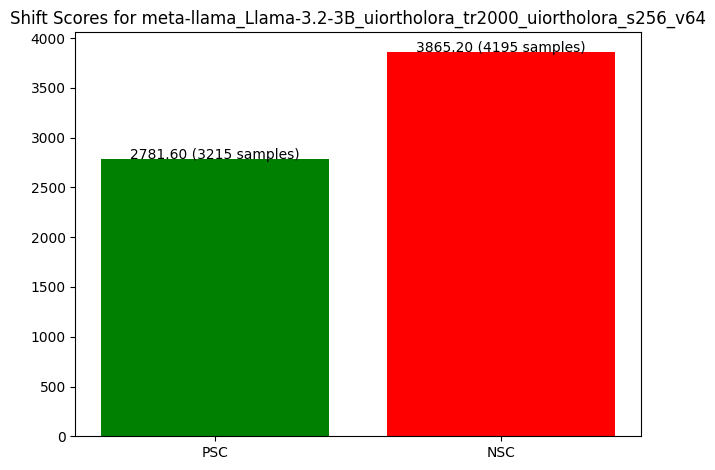

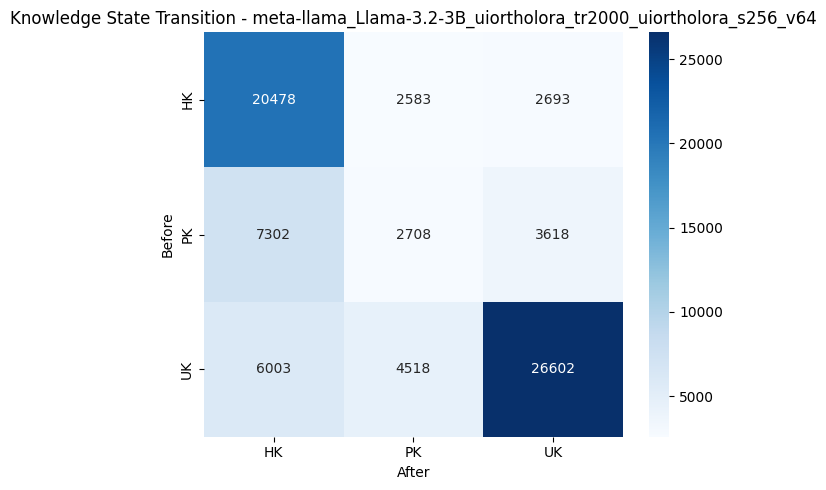

In [ ]:
if ft_model_names and df["base_model_id"].notna().any():
    for ft_model_name in uiortholora_adapter_models:
        base_model_name = df["base_model_id"].dropna().unique()[0]
        print(f"Evaluating FT model '{ft_model_name}' vs baseline '{base_model_name}'")
        evaluate_single_run(df, ft_model_name, base_model_name)

Evaluating FT model 'meta-llama_Llama-3.2-3B_lora_tr100_lora_r3' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_lora_tr100_lora_r3
Baseline: Llama-3.2-3B
Trained samples: 100
Accuracy: 0.066
PSC: 562.800 (797 samples)
NSC: 90.000 (133 samples)


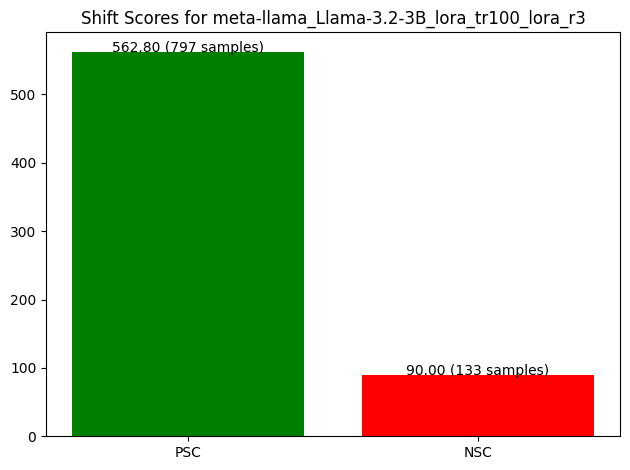

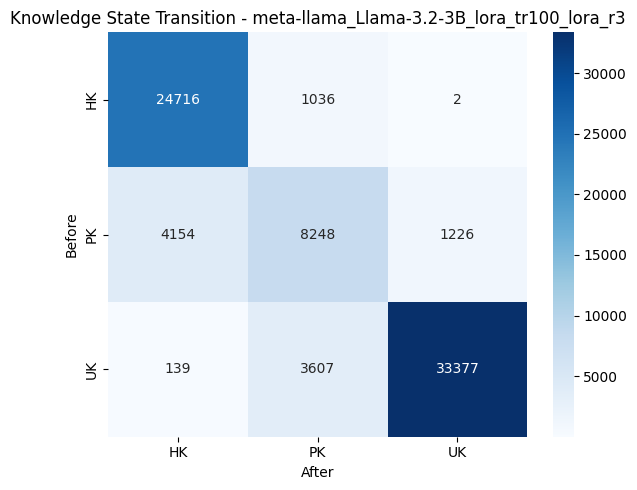

Evaluating FT model 'meta-llama_Llama-3.2-3B_lora_tr500_lora_r3' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_lora_tr500_lora_r3
Baseline: Llama-3.2-3B
Trained samples: 500
Accuracy: 0.185
PSC: 2641.600 (3055 samples)
NSC: 4092.800 (4441 samples)


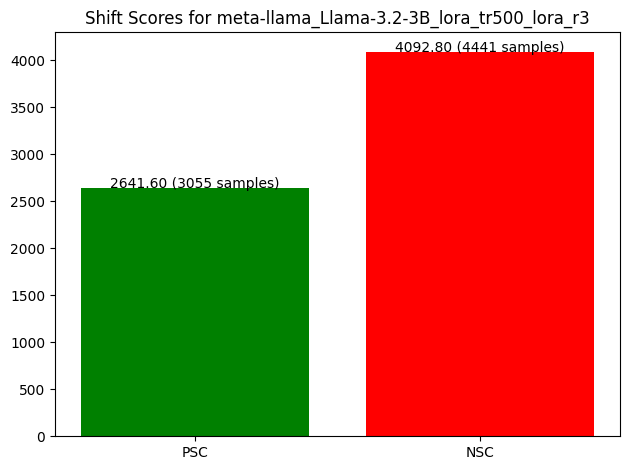

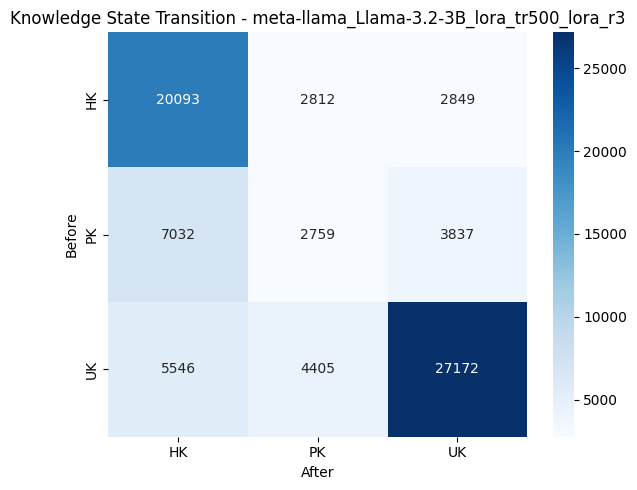

Evaluating FT model 'meta-llama_Llama-3.2-3B_lora_tr1000_lora_r3' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_lora_tr1000_lora_r3
Baseline: Llama-3.2-3B
Trained samples: 1000
Accuracy: 0.252
PSC: 2944.200 (3384 samples)
NSC: 3936.600 (4272 samples)


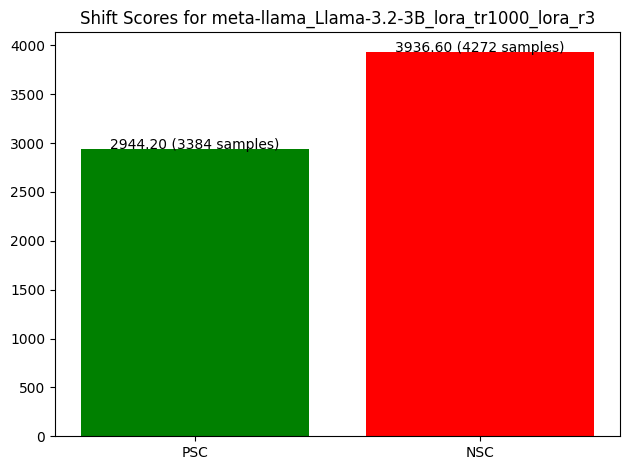

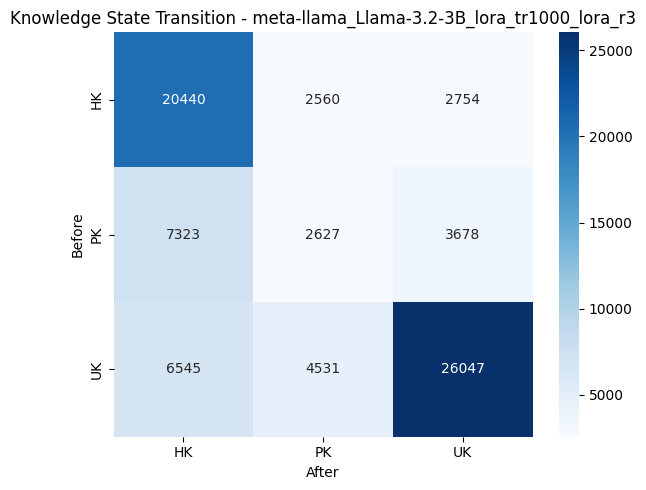

Evaluating FT model 'meta-llama_Llama-3.2-3B_lora_tr2000_lora_r3' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_lora_tr2000_lora_r3
Baseline: Llama-3.2-3B
Trained samples: 2000
Accuracy: 0.040
PSC: 345.800 (409 samples)
NSC: 22882.800 (23778 samples)


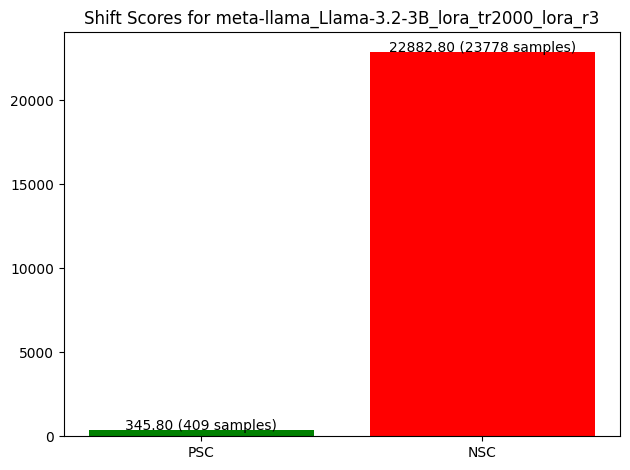

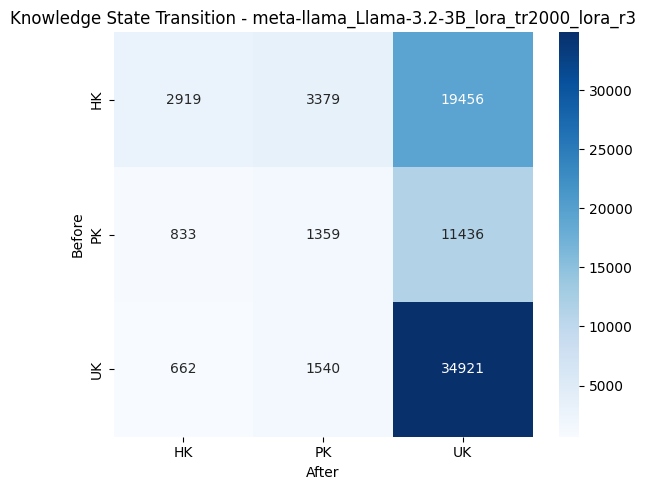

In [ ]:
if ft_model_names and df["base_model_id"].notna().any():
    for ft_model_name in lora_adapter_models:
        base_model_name = df["base_model_id"].dropna().unique()[0]
        print(f"Evaluating FT model '{ft_model_name}' vs baseline '{base_model_name}'")
        evaluate_single_run(df, ft_model_name, base_model_name)

Evaluating FT model 'meta-llama_Llama-3.2-3B_randlora_tr100_randlora_r512' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_randlora_tr100_randlora_r512
Baseline: Llama-3.2-3B
Trained samples: 100
Accuracy: 0.024
PSC: 112.800 (172 samples)
NSC: 158.800 (235 samples)


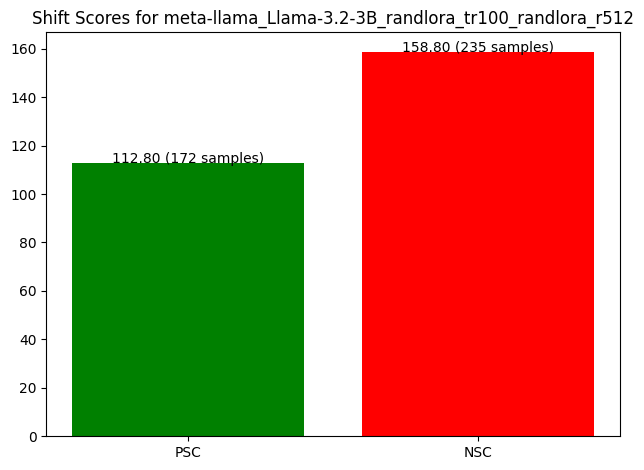

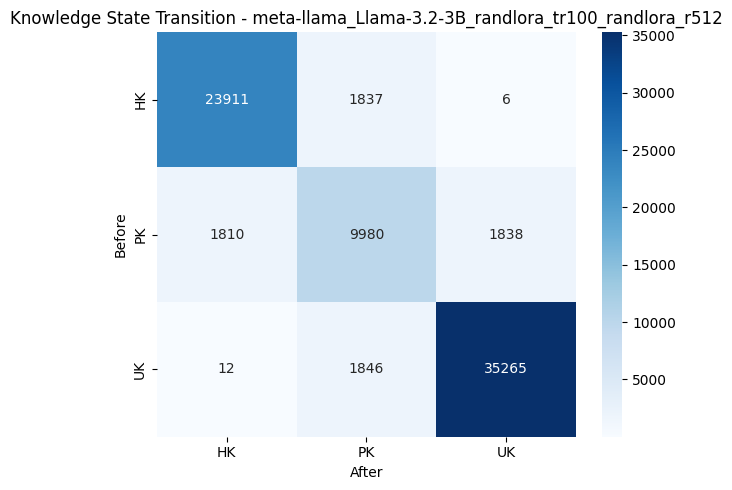

Evaluating FT model 'meta-llama_Llama-3.2-3B_randlora_tr500_randlora_r512' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_randlora_tr500_randlora_r512
Baseline: Llama-3.2-3B
Trained samples: 500
Accuracy: 0.020
PSC: 210.600 (325 samples)
NSC: 129.200 (193 samples)


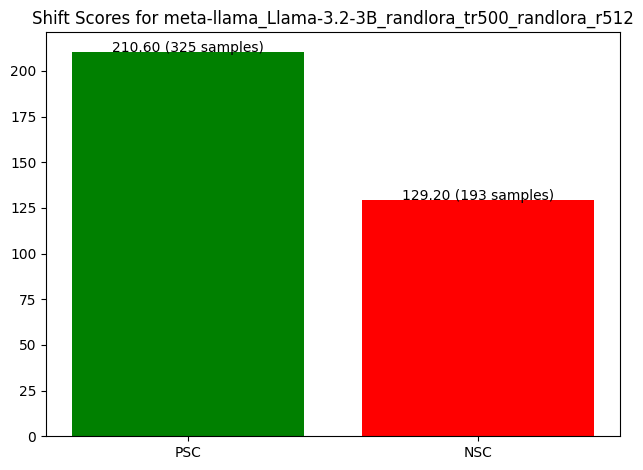

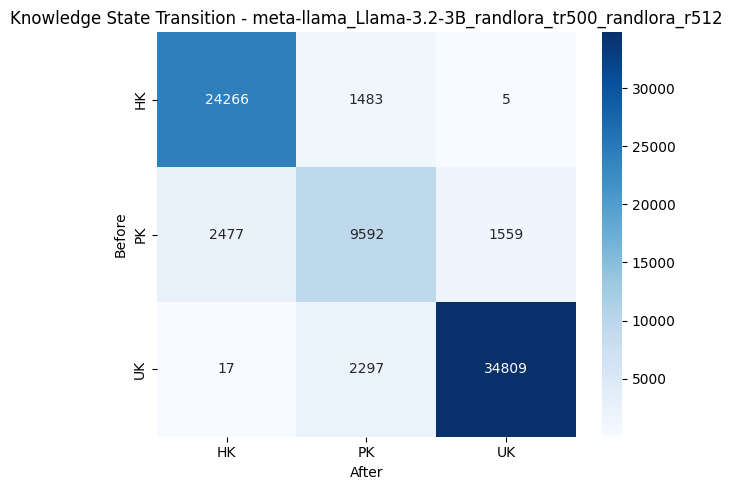

Evaluating FT model 'meta-llama_Llama-3.2-3B_randlora_tr1000_randlora_r512' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_randlora_tr1000_randlora_r512
Baseline: Llama-3.2-3B
Trained samples: 1000
Accuracy: 0.059
PSC: 900.800 (1190 samples)
NSC: 113.800 (160 samples)


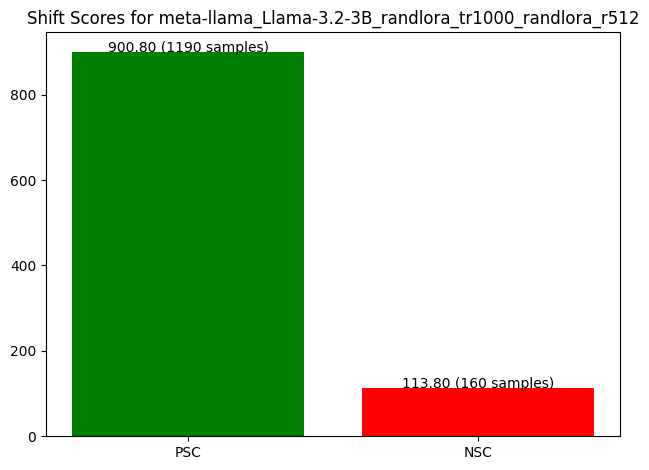

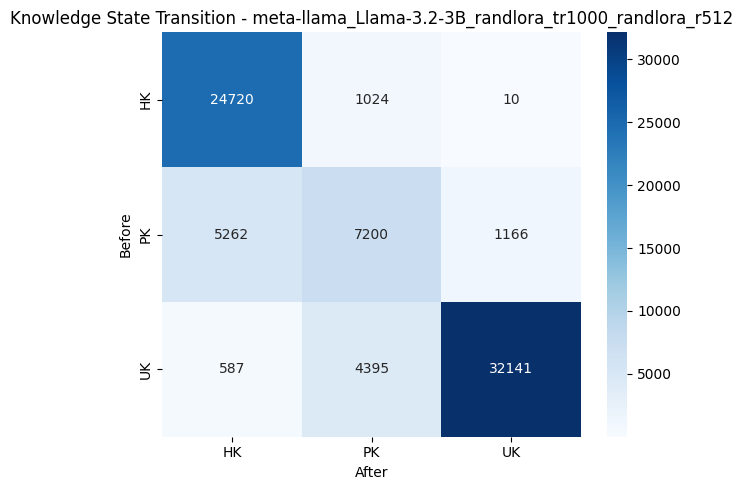

Evaluating FT model 'meta-llama_Llama-3.2-3B_randlora_tr2000_randlora_r512' vs baseline 'Llama-3.2-3B'
Adapter: meta-llama_Llama-3.2-3B_randlora_tr2000_randlora_r512
Baseline: Llama-3.2-3B
Trained samples: 2000
Accuracy: 0.167
PSC: 2268.800 (2692 samples)
NSC: 1158.200 (1357 samples)


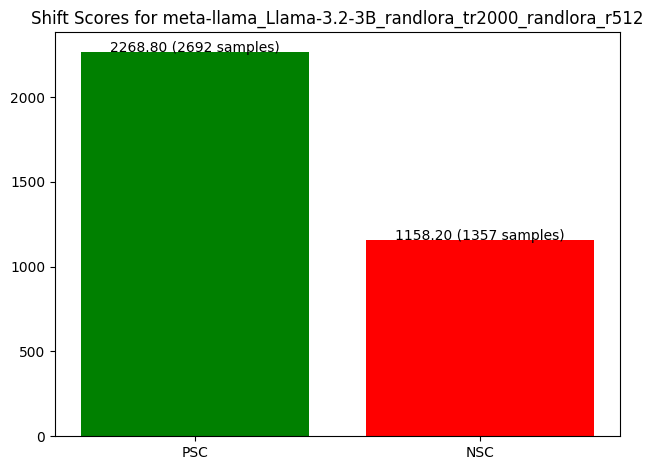

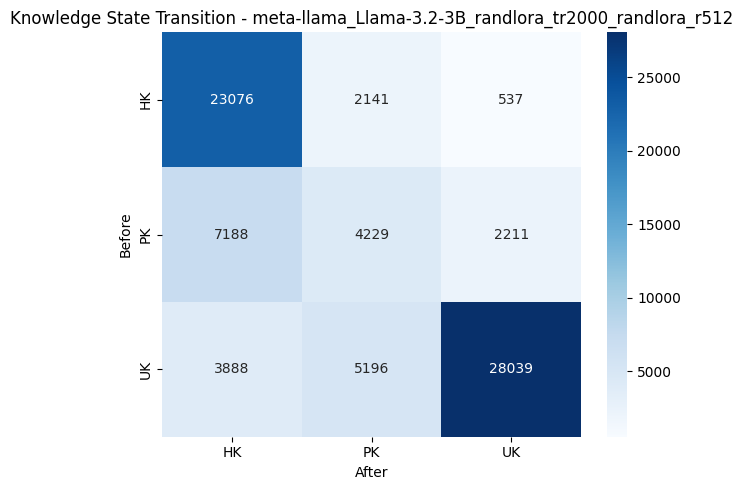

In [ ]:
if ft_model_names and df["base_model_id"].notna().any():
    for ft_model_name in randlora_adapter_models:
        base_model_name = df["base_model_id"].dropna().unique()[0]
        print(f"Evaluating FT model '{ft_model_name}' vs baseline '{base_model_name}'")
        evaluate_single_run(df, ft_model_name, base_model_name)